## Tips

## 📁 Column Metadata & Schema Reference

| Column Name | Data Type | Feature Type | Description | Example / Range |
| :--- | :--- | :--- | :--- | :--- |
| **`total_bill`** | `float64` | Continuous Numerical | Total expenditure for the meal (in USD) | `$3.07` to `$50.81` |
| **`tip`** | `float64` | Continuous Numerical | Tip amount given to server (in USD) | `$1.00` to `$10.00` |
| **`sex`** | `category` | Binary Categorical | Gender of the primary bill payer | `'Male'`, `'Female'` |
| **`smoker`** | `category` | Binary Categorical | Whether party was in a smoking section | `'Yes'`, `'No'` |
| **`day`** | `category` | Nominal Categorical | Day of the week transaction occurred | `'Thur'`, `'Fri'`, `'Sat'`, `'Sun'` |
| **`time`** | `category` | Nominal Categorical | Meal time category | `'Lunch'`, `'Dinner'` |
| **`size`** | `int64` | Discrete Numerical | Number of dining guests in the party | `1` to `6` people |

### 1. Notebook Setup & Data Inspection

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# set visual style
sns.set_theme(style="whitegrid")

# load built-in tips dataset
df = sns.load_dataset('tips')

# inspect structure and data types
print("Dataset Shape: ", df.shape)
print("\nData Types & Missing Values: ")
print(df.info())
df.head()

Dataset Shape:  (244, 7)

Data Types & Missing Values: 
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 2. Feature Engineering (Ratios & Metrics)
Raw tipping amounts can be misleading without contextual ratios. 
1. `tip_pct`: The tip percentage relative to the total bill (tip/total*100)
2. `bill_per_person`: The average expenditure per guest(total_bill/size)

In [2]:
# feature engineering
df_clean = df.copy() # creating copy so that the original copy won't be affected
df_clean['tip_pct'] = (df_clean['tip']/df_clean['total_bill']) * 100
df_clean['bill_per_person'] = df_clean['total_bill']/df_clean['size']

# review summary statistics
df_clean[['total_bill','tip', 'tip_pct', 'bill_per_person']].describe().round(2)

,total_bill,tip,tip_pct,bill_per_person
count,244.00,244.00,244.00,244.00
mean,19.79,3.00,16.08,7.89
std,8.90,1.38,6.11,2.91
min,3.07,1.00,3.56,2.88
25%,13.35,2.00,12.91,5.80
50%,17.80,2.90,15.48,7.26
75%,24.13,3.56,19.15,9.39
max,50.81,10.00,71.03,20.27


### 3. Distribution & Skewness Analysis (Target & Features)
Examine the shape of continuous variables. Pricing and tip distributions are often right-skewed.

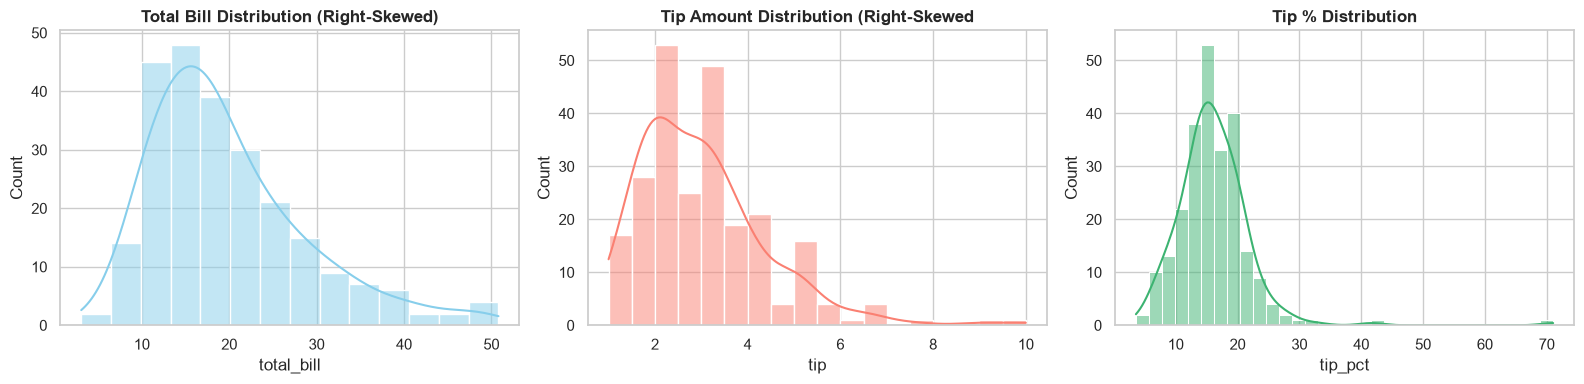

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4)) # 3 plots in 1 row

# 1. Total Bill Distribution
sns.histplot(df_clean['total_bill'], kde=True, ax=axes[0], color='skyblue') # in first plot => [0]
axes[0].set_title('Total Bill Distribution (Right-Skewed)', fontweight='bold')

# 2. Tip Amount Distribution
sns.histplot(df_clean['tip'], kde=True, ax=axes[1], color='salmon') # in second plot => [1]
axes[1].set_title('Tip Amount Distribution (Right-Skewed)', fontweight='bold')

# 3. Tip Percentage Distribution
sns.histplot(df_clean['tip_pct'], kde=True, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Tip % Distribution', fontweight='bold')

plt.tight_layout() # automatically adjusts subplot parameters to prevent overlapping of titles, labels, and ticks
plt.show()


`tip_pct` was calculated here [(tip/total bill) * 100] which measures how generous a party was relative to their total expenditure, rather than looking at the raw dollar amount alone.

#### The 16.08% result
1. 16.08% here means that on average (in the industry baseline),  customers in the restaurant datset tip 16.08% of their total bill.
2. This reflects healthy customer behavior. Considering that the `tips` dataset originated in North America and the standard customary tipping ranges between 15% and 20%, the mean of 16.08% shows that the overall customer base aligns very closely with standard tipping norms.

### The min and max result (based on summary statistics from item 2)
- Min: 3.56
- Max: 71
1. The minimum 3.56% means at least on party tipped significantly below average, which can be a potential indicator of poor service or unhappy customer.
2. The maximum 71% means an extreme high outlier (someone probably paid a small bill like `$7.08` and left a `$5.00` tip, resulting in massive percentage)

### Tip % Distribution (3rd chart) <= IMPORTANT
The third chart's distribution peaks around 15%-16% and then rapidly drops off. Because 71% is an extreme outlier, it pulls the arithmetic down. 

Chart 2 is about the raw dollar amount and it heavily right-skewed, but chart 3 is the standardize rate of that `tip`. Hence, `tip_pct` is used instead of `tip` that creates a proper bell-curved. 

### 4. Bivariate Linear Regression EDA (`total_bill` vs. `tip`)
Using `regplot` for linear regression.

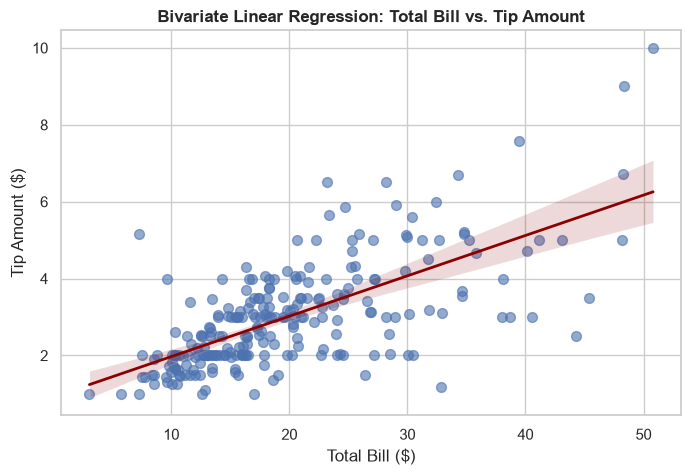

In [4]:
plt.figure(figsize=(8, 5))

# scatter plot with linear regression and 95% confidence interval
sns.regplot(
    data=df_clean,
    x='total_bill',
    y='tip',
    scatter_kws={'alpha':0.6, 's':50}, # set style of dot points in scatter plot
    line_kws={'color':'darkred', 'linewidth': 2} # set style of line in scatterplot
)

plt.title('Bivariate Linear Regression: Total Bill vs. Tip Amount', fontweight='bold', fontsize=12)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip Amount ($)')
plt.show()

### 5. Sub-Group Trend Analysis (Categorical Interactions)
Using `lmplot` to segment regression trends across categories.

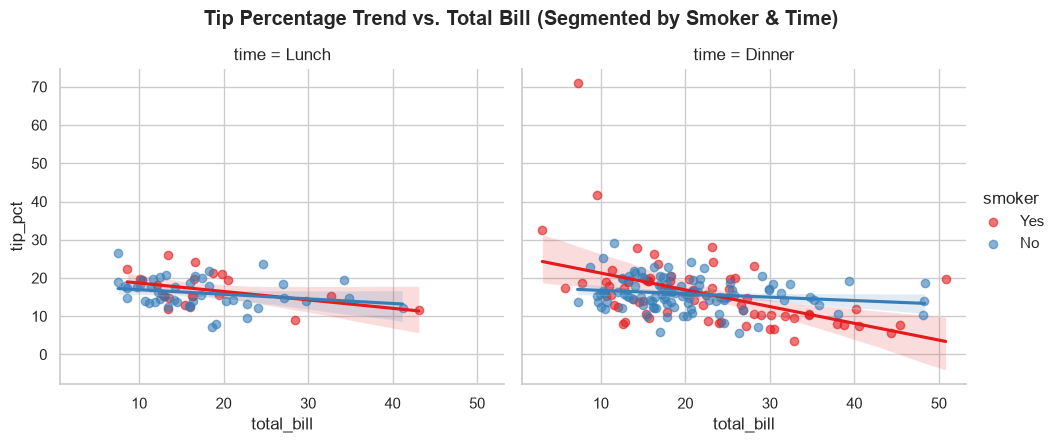

In [5]:
sns.lmplot(
    data=df_clean,
    x='total_bill',
    y='tip_pct',
    hue='smoker',
    col='time', # col MUST be a categorical column; separates plot columns based on the categories in `time` column
    palette='Set1',
    height=4.5, # vertical height of each indiv subplot canvas 
    aspect=1.1, # controls width relative to the height
    scatter_kws={'alpha': 0.6} 
)

plt.subplots_adjust(top=0.85) # moves top margin/ceiling of the plot area (to prevent the plots and labels to clash and overlap)
plt.suptitle('Tip Percentage Trend vs. Total Bill (Segmented by Smoker & Time)', fontweight='bold')
plt.show()

### `sns.lmplot` ("Linear Model Plot")
- draws a scatter plot to show individual data points
- fits a linear regression line to show the overall mathematical trend or direction of the data
- has built-in superpower to facet (split) data into multiple side-by-side subplots using categorical variables (like `cole = "time"` in this case)

#### How to read?
1. Focus on the regression line (trend direction)
2. Look at the data points (scatter/spread)
3. Look at the confidence interval (which is the shaded band and shows the uncertainty). Example in this case is the `total_bill`

Slope of Regression Line (Trend Direction)
1. Upward Slope (Positive Trend): as X-variable increases, the Y-variable also increases (e.g., higher total bills leads to larger tips)
2. Downward Slope (Negative Trend): as the X-variable decreases, the Y-variable also decreases (e.g., higher horsepower leads to lower fuel inefficiency)
3. Flat Horizontal Line (No Trend): changing the X-variable has zero effect on the Y-variable

Spread of Data Points
- points clustered tight to the line indicates **strong correlation**. Linear model predicts the relationship very accurately
- points scattered far away from the line indicates **weak correlation**. There's high variability, meaning there are other factors besides X are influencing Y

Translucent Shaded Band (Confidence Interval)
- shaded ribbon around regression line represents 95% CI for the regression line estimate
- narrow band: high certainty (lots of data points clustered together)
- wide/fan-shaped band: high uncertainty (happens at the extreme low or high ends of the plot where there are fewer data points)

### `regplot() vs lmplot()`
1. `regplot()`
   - axes-level function
   - draws directly onto a single matplotlib `Axes`
   - cannot split into multiple subplots
   - no native support (only colors all points one color)
   - best for single plots & custom subplot grids
2. `lmplot()`
   - figure-level function
   - creates new figure powered by `FacetGrid`
   - effortlessly creates grid subplots with `col=` and `row=`
   - can do color grouping by category
   - best for categorical comparisons & faceting
   
### When to use?
- use `sns.regplot()` when you want a quick, single plot comparing 2 continuous variables or when building a custom plot layout with `plt.subplots()`; for bivariate EDA
- use `sns.lmplot()` when you want to compare trends across categories using colors (`hue`), columns (`col`), or rows (`row`); for sub-group trend comparison, grid faceting, all-in-one categorical EDA

### Importance
1. For identifying direction & slope
   - whether 2 continuous variables have a positiove, negative, or zero relationship
2. Measure strength of relationship & variance (correlation quality)
   - to know how reliable the relationship is: tight clustering shows strong linear correlation (means X, the independent variable is a strong predictor of Y); wide scattering shows weak correlation (high variance means other hidden variables are influencing the outcome)
3. Evaluate model certainty & sample size (C.I.)
   - narrow ribbon: high confidence, plenty of data points in that range makes the trend reliable
   - fanning/wide ribbon: high uncertainty, typically occurs at extreme ends of a dataset where data points are scarce
4. Detect sub-group interactions & non-liner behaviors
   - exposes hidden sub-group anomalies such as Simpson's Paradox (occurs when a trend appears in several subgroups BUT reverses or disappears when groups combined, often due to hidden confounding variable)
5. spotting outliers & non-linear patterns
   - non-linear patterns mean the relationship of 2 variables does not foloow a straight line
   - it's crucial to know non-linear patterns so prevent the line to underpredict/overpredict values at the ends (which will make correlation score *r* artifically low or weak)
   - signals when to apply data transformation (`np.log1p`) especially for skewed datasets (will be shown below at item 6 in this notebook)

---


### 6. Log Transformation & Correlation Heatmap
To handle right-skewness and stabilize variance in regression relationships, we apply a logarithmic transformation (`np.log1p`) and compute the Pearson correlation matrix.

#### Why `np.log1p()` instead of `np.log()`?
This prevents mathematical errors. The standard `np.log()`, when there's a row with 0 value for instance, results Python to crash or produce `NaN` values. Adding `1` ensures log(0+1)=log(1)=0, making it completely safe. It also handles small numbers smoothly to prevent massive distortion at the low end of the dataset. Use `np.log()`if you're 100% certain that the dataset has no zero values (or negative values) in those columns. 

In short: log(0) produces error, so adding 1 => log(0+1) = log(1) = 0 **[SAFE!]**

#### What happens when we use skewed results without log transformations?
1. Regression line gets distorted (outliers pull line up)
    - in **item number 5**, we used regplots and lmplots using `tip_pct` (instead of `tip`) and `total_bill` without the need to apply log transformations. We used `tip_pct` [(tip/total bill) * 100] to stabilized and normalized the relationship, which reduced the need for log transformation
2. Heteroscedasticity (Unequal Variance)
    - C.I. becomes unreliable and predictions become inaccurate
3. Mean and standard deviation become misleading (which makes *r* less representative of the typical relationship when trying to use Pearson's correlation matrix)
4. Violates normality of residuals
    - causes skewed residuals, invalidating *p* values and statistical hypothesis (like F-tests, t-tests)

Note: *p*-value (probability value) is a number between 0 and 1 that tells the probability IF the pattern or difference happened **purely** or by **random chance**
1. p <=0.05 (statistically significant) => LESS than 5% chance that the results are fluke; strong evidence that a real relationship exists
2. p > 0.05 (not significant) => relationship could easily just be a **random noise**

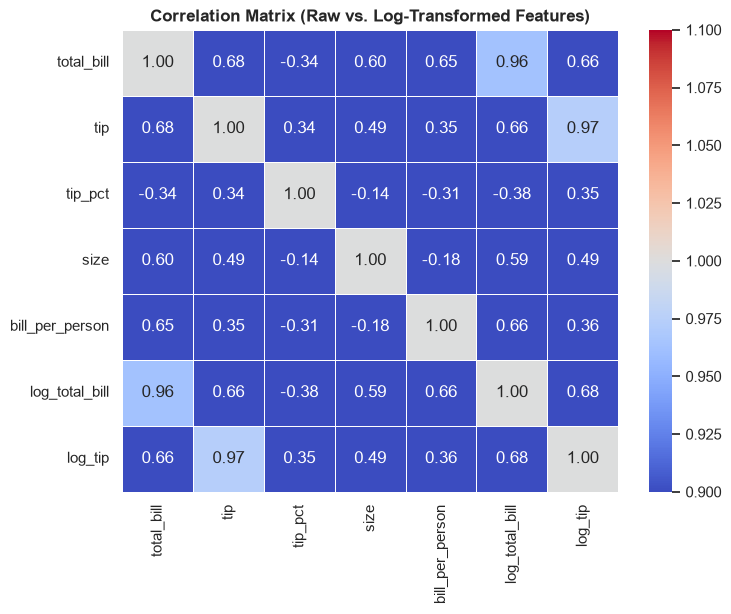

In [6]:
# apply log transformations to skewed variables
df_clean['log_total_bill'] = np.log1p(df_clean['total_bill']) # log1p() instead of log(0) to prevent python from crashing or produce NaN values
df_clean['log_tip'] = np.log1p(df_clean['tip'])

# select numeric columns for correlation matrix
numeric_cols = ['total_bill', 'tip', 'tip_pct', 'size', 'bill_per_person', 'log_total_bill', 'log_tip'] # (?) or do df_clean.select_dtypes(include=['float64', 'int64']) 
corr_matrix=df_clean[numeric_cols].corr()

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
           vmin=1, # what's the meaning of this?
           vmax=1, # what's the meaning of this?
           linewidths=0.5)
plt.title('Correlation Matrix (Raw vs. Log-Transformed Features)', fontweight='bold')
plt.show()

Note: 
- +0.70 to +1.00: strong positive; as X goes up, Y goes up strongly
- -0.70 to -1.00: strong negative (inverse); as X goes up, Y goes down
- -0.30 to -0.69: moderate negative (inverse); variables move in opposite directions moderately
- 0.00: no relationship at all

## Executive Summary & Key Analytical Findings

### 1. Primary Regression Trend (Total Bill vs. Tip)
* **Positive Correlation:** There is a strong positive linear relationship between `total_bill` and absolute `tip` amount ($r \approx 0.68$). [cite_start]As the bill increases, the dollar amount tipped generally increases[cite: 102].
* **Diminishing Returns (Tip Percentage):** While the total dollar tip increases with larger bills, the **tip percentage (`tip_pct`) exhibits a slight negative slope**. Higher total bills tend to yield lower overall tip percentages compared to smaller bills.

---

### 2. Sub-Group Interactions
* **Smokers vs. Non-Smokers:** Non-smokers display a consistent, steady tipping behavior. Smokers show significantly higher variance (higher volatility in tip percentages, including noticeable high-end outliers).
* **Party Size & Per-Person Cost:** Party size (`size`) correlates moderately with total bill ($r \approx 0.60$), but individual contribution (`bill_per_person`) is a stronger driver of higher percentage tipping.

---

### 3. Skewness & Data Transformations
* Both `total_bill` and `tip` exhibit noticeable right-skewness[cite: 160]. 
* [cite_start]Applying a logarithmic transformation (`log_total_bill` and `log_tip`) linearizes the variance, stabilizing features for linear regression modeling.